<a href="https://colab.research.google.com/github/laur-park/dsci235-final-project/blob/main/Diddi_Parker_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **You Are What You Can Afford: Diet, Income, and Success in College**



Lauren Parker & Isha Diddi

Professor Gaddy

DSCI 235

27 April 2026

### Introduction

Paragraph

### Part 1: Relationships Between Income, Health, Personal Beliefs, and Student Academic Performance


---



**A. Data Cleaning & Exploration**

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
data1 = pd.read_csv('cleanedfooddata.csv')
data1.head()


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,3.654,1,1,610,3,420,2,"chocolate, chips, ice cream","Stress, bored, anger",1,...,1,1,2,725,690,Basketball,4,2,900,155
1,3.300,1,1,720,4,420,2,"frozen yogurt, pizza, fast food","stress, sadness",1,...,1,2,5,1165,500,none,5,1,900,I'm not answering this.
2,3.500,1,1,720,2,420,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1,...,1,1,4,940,500,Softball,4,2,760,190
3,3.800,2,1,610,3,420,2,"Chocolate, ice cream, french fries, pretzels","stress, boredom",1,...,1,1,5,940,690,soccer,4,1,1315,180
4,3.300,1,1,720,3,420,1,"Ice cream, cheeseburgers, chips.",I eat comfort food when im stressed out from s...,1,...,1,2,1,725,500,none,4,2,1315,137


In [80]:
# columns we will use: GPA (open-ended,0), (family) income (interval,32), fruit_day
# (interval,24), veggies_day (interval,51), employment (interval,14), health_feeling (interval,27)

To begin this project, our team downloaded the main dataset for part one of the project, *Cleaned Food Data*. This file was orginally an Excel sheet, so we had to convert it into a CSV file.

After examining the dataset, our team made sure to highlight and comment on which specific variables would be utilized for this project.


In [81]:
refer_to = pd.read_csv('codebook.csv')
refer_to = refer_to.iloc[:55, :4]
refer_to.head()

,Variables,Responses,Question,Type of Variable
0,GPA,open ended,What is your GPA?,open-ended
1,Gender,1 = Female\n2 = Male,What is your gender?,interval
2,breakfast,1 = cereal option\n2 = donut option,the participants are shown the following pictu...,interval
3,calories_chicken,open ended,guessing calories in chicken piadina,interval
4,calories_day,1 - i dont know how many calories i should con...,Importance of consuming calories per day,interval


We observed that not all variable names were specific. The lack of specificity in the variable name confused us: what does the variable truly represent? Many categorical variables also contained numerical values (e.g., 1, 2, 3), suggesting that the surveyors utilized label encoding (each category is associated with a numerical value) for their study.

We were able to obtain the codebook for *Cleaned Food Data* dataset (shown above). This dataframe describes each variable, including the survey question presented to participants, the type of variable, and how responses were encoded. This codebook helped us better understand the data we were using.



**B. Developing a relationship between family income and the likelihood of consuming fruits and vegetables.**

In [82]:
display(refer_to.iloc[31, :])
# 1 - less than \$15,000
# 2 - \$15,001 to \$30,000
# 3 - \$30,001 to \$50,000
# 4 - \$50,001 to \$70,000
# 5 - \$70,001 to \$100,000
# 6 - higher than \$100,000

,31
Variables,income
Responses,"1 - less than $15,000 \n2 - $15,001 to $30,000..."
Question,what is your family income?
Type of Variable,interval


In [83]:
display(refer_to.iloc[24, :])
# 1 - very unlikely
# 2 - unlikely
# 3 - neutral
# 4 - likely
# 5 - very likely

,24
Variables,fruit_day
Responses,\n1 - very unlikely \n2 - unlikely \n3 - neutr...
Question,How likely to eat fruit in a regular day
Type of Variable,interval


To test the relationship between family income and the likelihood of consuming fruits, we utilized the variables 'income' and 'fruit_day'. Both are categorical variables that utilize label encoding.

In [84]:
data1.groupby('income')['fruit_day'].mean()

,fruit_day
income,
2,5.000000
3,4.250000
4,4.333333
5,4.666667
6,4.090909


First, we calculated the mean likelihood of consuming fruit per income group. All income groups achieved a score of 4 or higher: A 4-5 score is associated with "likely"-"very likely". All income groups were atleast likely to consume a fruit in a day. It is important to notice the perfect score of 5 for income group 2 (ranging from $15,001-$30,000) came from one individual. However, there does not appear to have a direct positive or negative relationship.

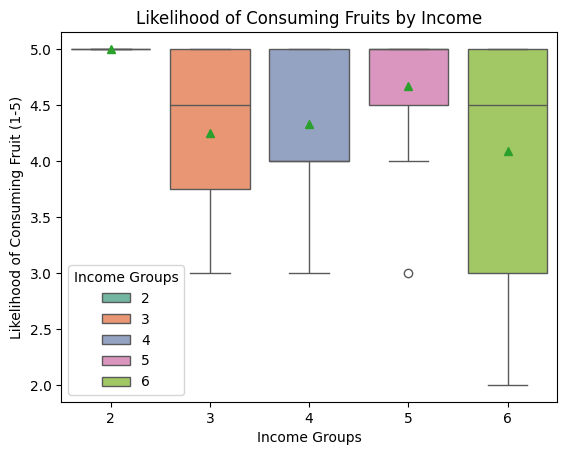

In [85]:
boxplot1 = sns.boxplot(data=data1, x='income', y='fruit_day', showmeans=True, hue='income', palette="Set2")
boxplot1.set_title('Likelihood of Consuming Fruits by Income')
boxplot1.set_ylabel('Likelihood of Consuming Fruit (1-5)')
boxplot1.set_xlabel('Income Groups')
plt.legend(title="Income Groups")


Plotting a boxplot of the likelihood of consuming fruit per income group allowed our team to visualize the variance within each group. The lack of "box" in boxplot representing income group 2 demonstrates the singular observation. There is a slight positive relationship between income groups three through five, indicating that the increase in income may correlate with a greater likelihood of consuming fruit.

In [86]:
data1.groupby('income')[['veggies_day']].mean()

,veggies_day
income,
2,5.000000
3,3.500000
4,4.222222
5,4.333333
6,3.954545


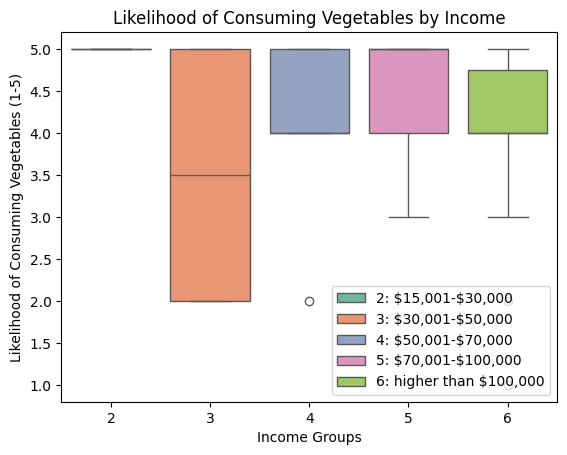

In [106]:
boxplot2 = sns.boxplot(data=data1, x='income', y='veggies_day', hue='income', palette="Set2")
boxplot2.set_title('Likelihood of Consuming Vegetables by Income')
boxplot2.set_ylabel('Likelihood of Consuming Vegetables (1-5)')
boxplot2.set_xlabel('Income Groups')
plt.legend([r'2: \$15,001-\$30,000', r'3: \$30,001-\$50,000 ', r'4: \$50,001-\$70,000', r'5: \$70,001-\$100,000', r'6: higher than \$100,000'])

**C. Exploring how working status may influence a student’s likelihood to consume fruit and vegetables.**

In [88]:
data1.groupby('employment')['fruit_day'].mean()

,fruit_day
employment,
1,5.000000
2,4.142857
3,4.545455


In [89]:
data1.groupby('employment')['veggies_day'].mean()

,veggies_day
employment,
1,5.000000
2,3.892857
3,4.318182


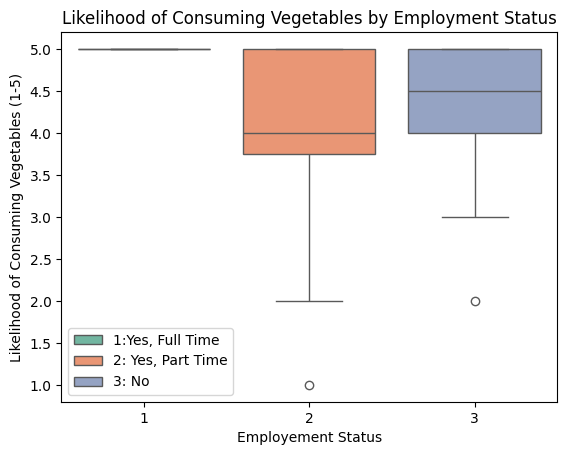

In [90]:
boxplot3 = sns.boxplot(data=data1, x='employment', y='veggies_day', hue='employment', palette="Set2")
boxplot3.set_title('Likelihood of Consuming Vegetables by Employment Status')
boxplot3.set_ylabel('Likelihood of Consuming Vegetables (1-5)')
boxplot3.set_xlabel('Employement Status')
plt.legend(['1:Yes, Full Time','2: Yes, Part Time', '3: No'])



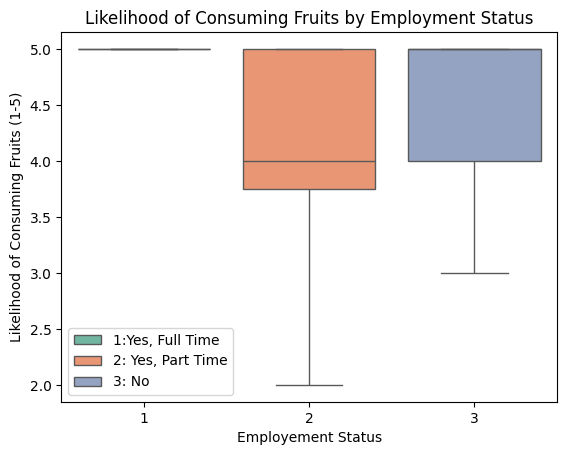

In [91]:
boxplot4 = sns.boxplot(data=data1, x='employment', y='fruit_day', hue='employment', palette="Set2")
boxplot4.set_title('Likelihood of Consuming Fruits by Employment Status')
boxplot4.set_ylabel('Likelihood of Consuming Fruits (1-5)')
boxplot4.set_xlabel('Employement Status')
plt.legend(['1:Yes, Full Time','2: Yes, Part Time', '3: No'])

**D. Determine whether health status and GPA are correlated.**


To quantify health status, we will be using the column health_feeling. Students answered a statement "I feel very healthy!" with a number in a range from 1-10, with 1 being "strongly disagree" and 10 being "strongly agree".

**E. Assess the relationship between family income and GPA.**

For this question, we will use the columns "income" and "GPA". Income is an interval variable with a range from 1-6 where 1 represents a family income of <\\$15,000, 2 represents a family income of \\$15,001-\\$30,000, 3 represents a family income of \\$30,001-\\$50,000, 4 represents a family income of \\$50,001-\\$70,000, 5 represents a family income of \\$70,001-\\$100,000, and 6 represents a family income of >\\$100,001. GPA is an open-ended, float variable with a range from 0.0-4.0.

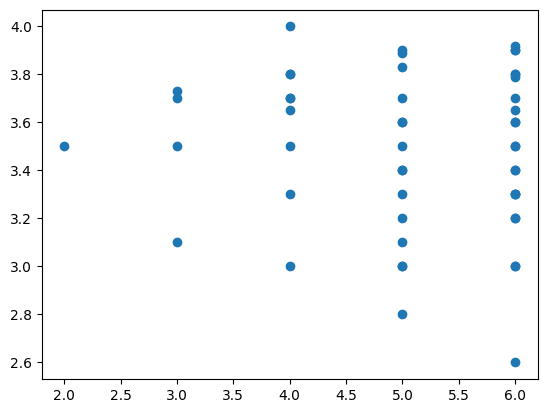

In [107]:
x_income = data1['income']
y_GPA = data1['GPA']
plt.scatter(x_income,y_GPA)

First, I started by making a simple scatter plot. This scatterplot made it seem like there was only ~30 data points when the data set contains 51. The x-axis was also formatted weirdly. There are 6 categories of family income level in the dataset, but the axis-labels were 2.0-6.0 at intervals of 0.5. This graph shows no obvious relationship between GPA and family income, however, there is very inconsistent variance.

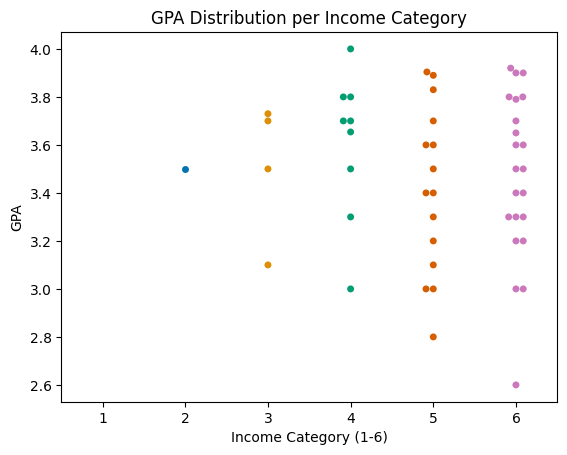

In [93]:
plt.figure()
sns.swarmplot(x=x_income, y=y_GPA, hue=x_income, palette='colorblind', legend=False, order=[1,2,3,4,5,6])
plt.title('GPA Distribution per Income Category')
plt.xlabel('Income Category (1-6)')
plt.show()

This plot looks much better than our first plot as we have, using the seaborn package, jittered the data points, so we can see the overlapping ones, we have added axis labels and a title, and we have colored the points for visual appeal. We also added an axis label for Income Category 1 since it was one of the options in the survey, although it didn't apply to any respondents so we don't have any data for it.

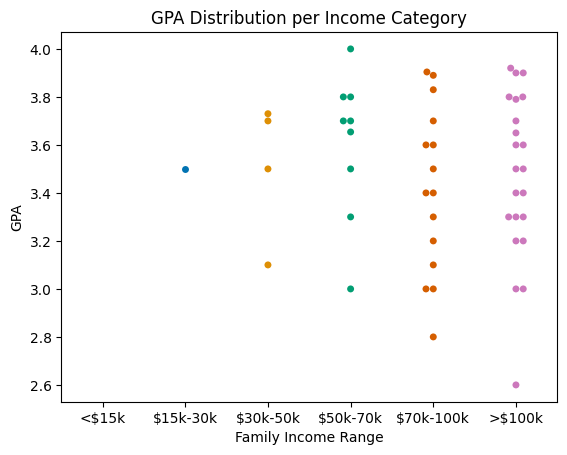

In [94]:
income_labels = ['<$15k', '$15k-30k', '$30k-50k', '$50k-70k', '$70k-100k', '>$100k']
plt.figure()
sns.swarmplot(x=x_income, y=y_GPA, hue=x_income, palette='colorblind', legend=False, order=[1,2,3,4,5,6])
plt.title('GPA Distribution per Income Category')
plt.xlabel('Family Income Range')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5], labels=income_labels)
plt.show()

To make it clearer for those who aren't familar with this dataset, the only thing I changed with this scatter plot is that I simply relabeled the income categories with the income levels that they represent.

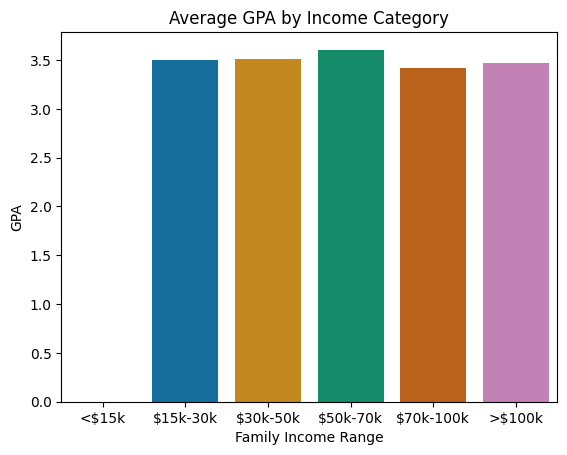

In [95]:
plt.figure()
sns.barplot(x=x_income, y=y_GPA, hue=x_income, palette='colorblind', legend=False, order=[1,2,3,4,5,6], errorbar=None)
plt.xticks(ticks=[0,1,2,3,4,5], labels=income_labels)
plt.title('Average GPA by Income Category')
plt.xlabel('Family Income Range')
plt.show()

This chart shows the mean GPAs for each income category. We can see that all 5 of these look pretty similar and all averages are around 3.5. This plot doesn't show any indications of a relationship between income and GPA.

In [96]:
income_cat_means = data1.groupby('income')['GPA'].mean()
income_cat_means

,GPA
income,
2,3.500000
3,3.507500
4,3.606000
5,3.414933
6,3.470909


Since the average GPAs in the barplot were too close together to be able to see any differences between them or any patterns, it is relevant to simply compute the means. Here we can still see that the average GPAs per category are no more than 0.2 GPA points apart from each other, but we do see a slight upside-down U shape. There does not seem to be a positive or negative linear relationship to these means, there is a slight curve.

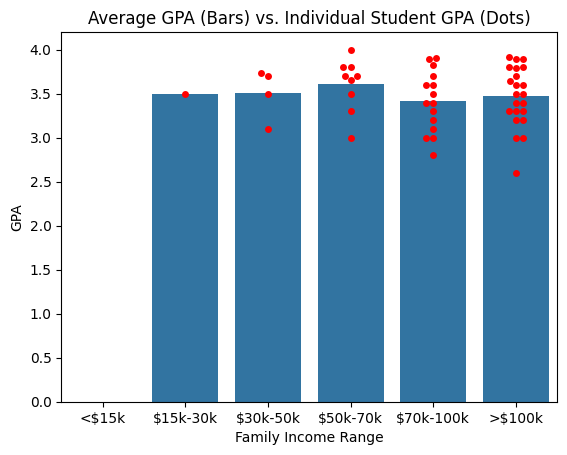

In [97]:
plt.figure()
sns.barplot(x=x_income, y=y_GPA, order=[1,2,3,4,5,6], errorbar=None)
sns.swarmplot(x=x_income, y=y_GPA, color='red')
plt.xticks(ticks=[0,1,2,3,4,5], labels=income_labels)
plt.title('Average GPA (Bars) vs. Individual Student GPA (Dots)')
plt.xlabel('Family Income Range')
plt.show()

Here I made a plot combining the scatterplot of the data and the boxplot of the category means from above, just to see this data in one place.

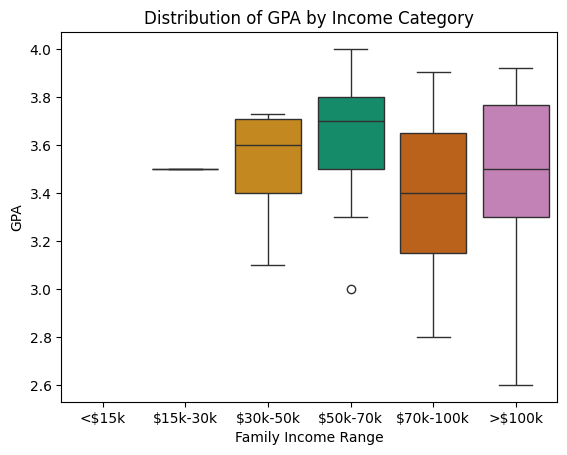

In [98]:
plt.figure()
sns.boxplot(x=x_income, y=y_GPA, hue=x_income, palette='colorblind', legend=False, order=[1,2,3,4,5,6])
plt.xticks(ticks=[0,1,2,3,4,5], labels=income_labels)
plt.title('Distribution of GPA by Income Category')
plt.xlabel('Family Income Range')
plt.show()

This boxplot is probably the best visualization tool for this data. It shows the means per category as well as the spread of the data and outlier data points. This chart shows that although the means are similar, the amount of data in each category varies widely which may make it difficult to interpret any patterns from these results. Income category 1 has only one data point so the mean line, box, and whiskers are the same line. Income categories 5 & 6 have much larger box widths and whisker lengths than categories 3 & 4. From this data, we do not see any clear relationship between family income and GPA, but if we had more data, we may have been able to detect a pattern.

In [99]:
samplesize_cat_means = data1.groupby('income')['GPA'].count()
samplesize_cat_means

,GPA
income,
2,1
3,4
4,9
5,15
6,22


Using groupby, we can see the differences in sample size per income category that will make it difficult to determine patterns from this data. Maybe if the survey had had participants list their exact family income instead of selecting an income range, we could've derived more meaningful results from this data.

**F. Overall Analyses**

### Part 2: Affordability of Maintaining a Healthy Diet

---



**A. Data Cleaning & Exploration**

In [100]:
fruity = pd.read_csv('fruit-prices-2023.csv')
fruity.head()

,Fruit,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure,PreparationYieldFactor,SizeOfACupEquivalent,CupEquivalentUnitOfMeasure,AveragePricePerCupEquivalent
0,Apples,Fresh,1.860931,per pound,0.90,0.2425,pounds,0.501435
1,"Apples, applesauce",Canned,1.208099,per pound,1.00,0.5401,pounds,0.652534
2,"Apples, ready to drink",Juice,0.951115,per pint (16 fluid ounces ready to drink),1.00,0.5000,pints,0.475558
3,"Apples, frozen concentrate",Juice,2.668334,per pint (16 fluid ounces concentrate),4.00,0.5000,pints,0.333542
4,Apricots,Fresh,3.803732,per pound,0.93,0.3638,pounds,1.487802


In [101]:
veggie = pd.read_csv('vegetable-prices-2023.csv')
veggie.head()

,Vegetable,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure,PreparationYieldFactor,SizeOfACupEquivalent,CupEquivalentUnitOfMeasure,AveragePricePerCupEquivalent
0,Acorn squash,Fresh,1.241439,per pound,0.4586,0.4519,pounds,1.223533
1,Artichoke,Fresh,2.506856,per pound,0.3750,0.3858,pounds,2.080461
2,Artichoke,Canned,3.505101,per pound,0.6500,0.3858,pounds,2.579113
3,Asparagus,Fresh,3.212453,per pound,0.4938,0.3968,pounds,2.581436
4,Asparagus,Canned,3.676296,per pound,0.6500,0.3968,pounds,2.244419


**B.  Estimating the cost per serving of fruit**

**C. Estimating the cost per serving of vegetables**

**D. Overall Analyses**

### Conclusion